In [ ]:
#import libraries
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load dataset
df= pd.read_csv('/content/bank-additional-full.csv')

##1. Understand and Explore the Dataset

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.shape

(41188, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
df.isna().sum() # no null values

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
df.duplicated().sum()

np.int64(12)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum() #check

np.int64(0)

In [ ]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41176,41176,41176,41176,41176,41176,41176,41176,41176,41176,41176
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10419,24921,12164,32577,21571,33938,26135,13767,8618,35551,36537


In [ ]:
df.shape

(41176, 21)

In [ ]:
df['y'].value_counts()
#data imbalance is here

,count
y,
no,36537
yes,4639


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

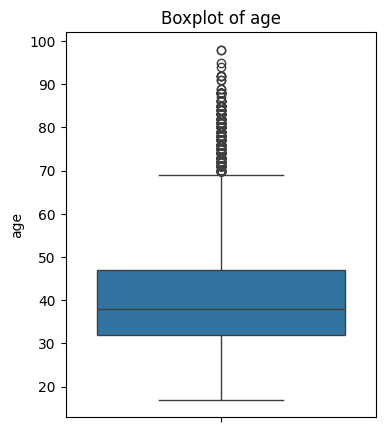

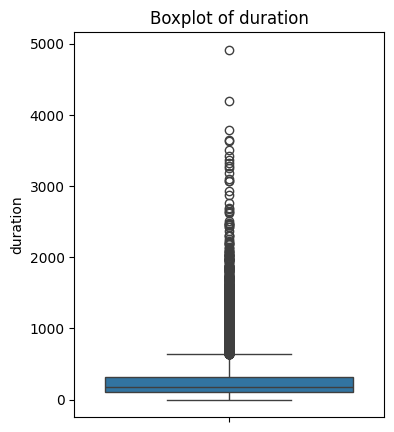

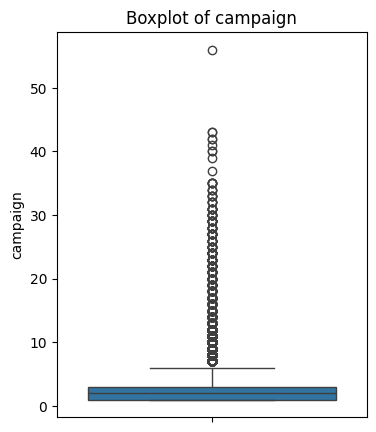

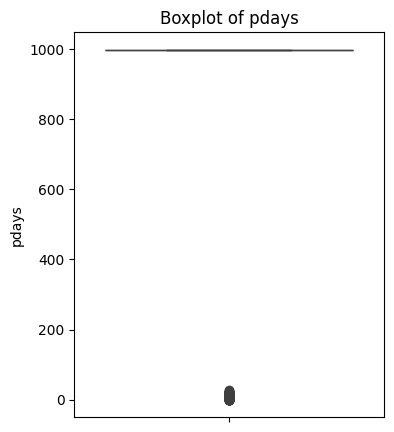

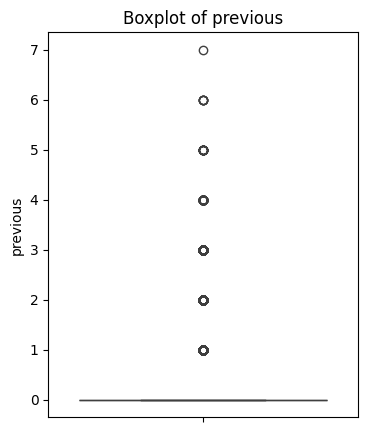

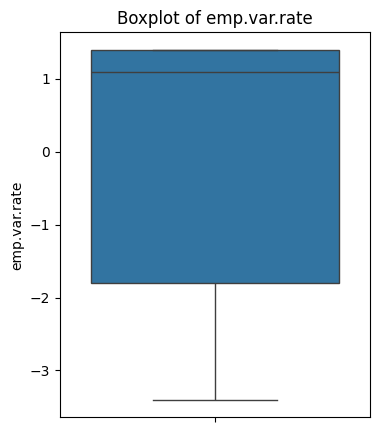

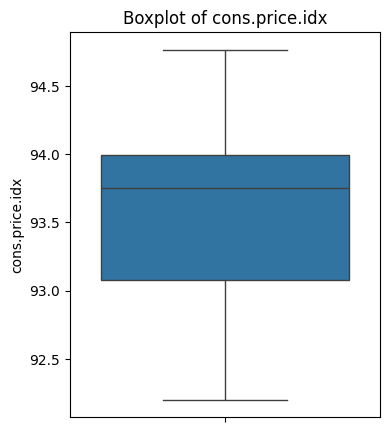

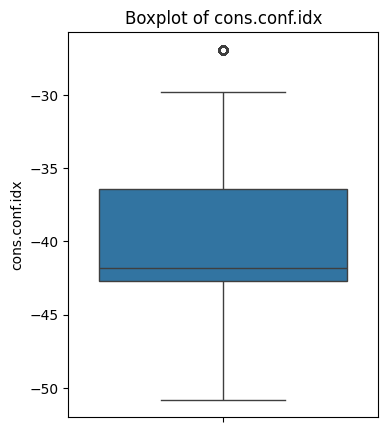

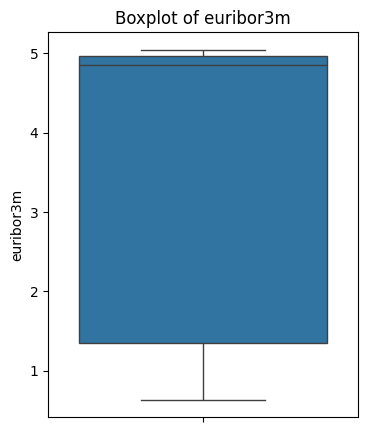

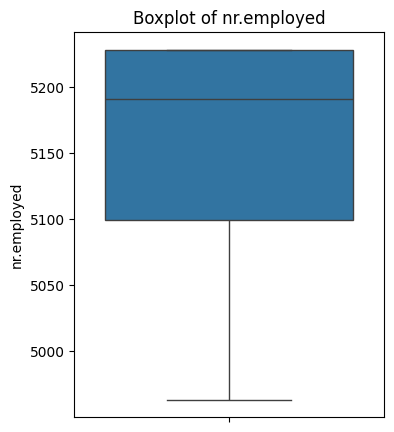

In [ ]:
for col in num_cols:
    plt.figure(figsize=(4,5))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

##2. Data Preprocessing

In [ ]:
# no missing values  but unknown is replace with mode

In [ ]:
# Separate numerical and categorical columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include='object').columns

In [ ]:
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [ ]:
for col in cat_cols:
    if 'unknown' in df[col].values:
        mode_value = df.loc[df[col] != 'unknown', col].mode()[0]
        df[col] = df[col].replace('unknown', mode_value)

In [ ]:
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df['default'].value_counts()

,count
default,
no,41173
yes,3


<Axes: >

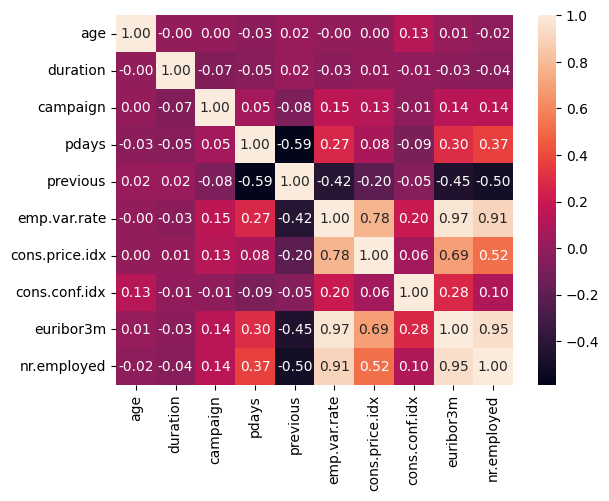

In [ ]:
df_numeric_corr = df.corr(numeric_only=True)
sns.heatmap(df_numeric_corr, annot=True, fmt='.2f')

In [ ]:
display(df_numeric_corr.style.format("{:.2f}"))

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.00,-0.00,0.00,-0.03,0.02,-0.00,0.00,0.13,0.01,-0.02
duration,-0.00,1.00,-0.07,-0.05,0.02,-0.03,0.01,-0.01,-0.03,-0.04
campaign,0.00,-0.07,1.00,0.05,-0.08,0.15,0.13,-0.01,0.14,0.14
pdays,-0.03,-0.05,0.05,1.00,-0.59,0.27,0.08,-0.09,0.30,0.37
previous,0.02,0.02,-0.08,-0.59,1.00,-0.42,-0.20,-0.05,-0.45,-0.50
emp.var.rate,-0.00,-0.03,0.15,0.27,-0.42,1.00,0.78,0.20,0.97,0.91
cons.price.idx,0.00,0.01,0.13,0.08,-0.20,0.78,1.00,0.06,0.69,0.52
cons.conf.idx,0.13,-0.01,-0.01,-0.09,-0.05,0.20,0.06,1.00,0.28,0.10
euribor3m,0.01,-0.03,0.14,0.30,-0.45,0.97,0.69,0.28,1.00,0.95
nr.employed,-0.02,-0.04,0.14,0.37,-0.50,0.91,0.52,0.10,0.95,1.00


In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [ ]:
df = df.drop(columns=['emp.var.rate', 'nr.employed'])

In [ ]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,cons.price.idx,cons.conf.idx,euribor3m,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,93.994,-36.4,4.857,no
1,57,services,married,high.school,no,no,no,telephone,may,mon,149,1,999,0,nonexistent,93.994,-36.4,4.857,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,93.994,-36.4,4.857,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,93.994,-36.4,4.857,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,93.994,-36.4,4.857,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,94.767,-50.8,1.028,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,94.767,-50.8,1.028,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,94.767,-50.8,1.028,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,94.767,-50.8,1.028,yes


<Axes: >

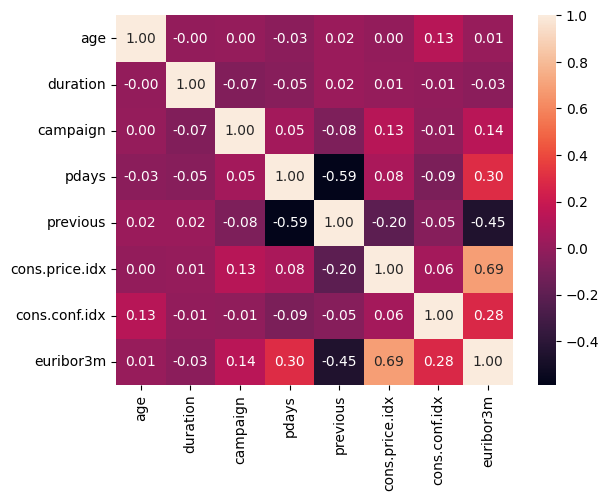

In [ ]:
df_numeric_corr = df.corr(numeric_only=True)
sns.heatmap(df_numeric_corr, annot=True, fmt='.2f')

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,cons.price.idx,cons.conf.idx,euribor3m,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,93.994,-36.4,4.857,no
1,57,services,married,high.school,no,no,no,telephone,may,mon,149,1,999,0,nonexistent,93.994,-36.4,4.857,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,93.994,-36.4,4.857,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,93.994,-36.4,4.857,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,93.994,-36.4,4.857,no


In [ ]:
df['contact'].value_counts()

,count
contact,
cellular,26135
telephone,15041


In [ ]:
df = df.drop('duration', axis=1)

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,cons.price.idx,cons.conf.idx,euribor3m,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no
1,57,services,married,high.school,no,no,no,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,93.994,-36.4,4.857,no


In [ ]:
cat_col=df[['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome']]

In [ ]:
cat_col

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent
1,services,married,high.school,no,no,no,telephone,may,mon,nonexistent
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent
...,...,...,...,...,...,...,...,...,...,...
41183,retired,married,professional.course,no,yes,no,cellular,nov,fri,nonexistent
41184,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,nonexistent
41185,retired,married,university.degree,no,yes,no,cellular,nov,fri,nonexistent
41186,technician,married,professional.course,no,no,no,cellular,nov,fri,nonexistent


In [ ]:
df = pd.get_dummies(df, columns=cat_col.columns, drop_first=True, dtype=int)

In [ ]:
df['y'] = df['y'].map({'no': 0, 'yes': 1})

In [ ]:
df

,age,campaign,pdays,previous,cons.price.idx,cons.conf.idx,euribor3m,y,job_blue-collar,job_entrepreneur,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,999,0,93.994,-36.4,4.857,0,0,0,...,1,0,0,0,1,0,0,0,1,0
1,57,1,999,0,93.994,-36.4,4.857,0,0,0,...,1,0,0,0,1,0,0,0,1,0
2,37,1,999,0,93.994,-36.4,4.857,0,0,0,...,1,0,0,0,1,0,0,0,1,0
3,40,1,999,0,93.994,-36.4,4.857,0,0,0,...,1,0,0,0,1,0,0,0,1,0
4,56,1,999,0,93.994,-36.4,4.857,0,0,0,...,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,999,0,94.767,-50.8,1.028,1,0,0,...,0,1,0,0,0,0,0,0,1,0
41184,46,1,999,0,94.767,-50.8,1.028,0,1,0,...,0,1,0,0,0,0,0,0,1,0
41185,56,2,999,0,94.767,-50.8,1.028,0,0,0,...,0,1,0,0,0,0,0,0,1,0
41186,44,1,999,0,94.767,-50.8,1.028,1,0,0,...,0,1,0,0,0,0,0,0,1,0


In [ ]:
df.shape

(41176, 45)

<Figure size 2300x3800 with 0 Axes>

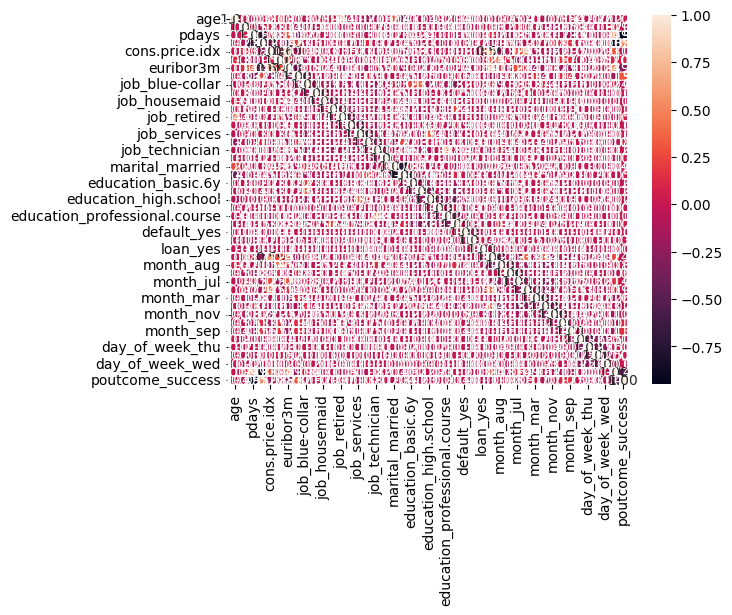

<Figure size 2300x3800 with 0 Axes>

In [ ]:
df_numeric_corr = df.corr(numeric_only=True)
sns.heatmap(df_numeric_corr, annot=True, fmt='.2f')
plt.figure(figsize=(23,38))

In [ ]:
df['pdays'].value_counts()

,count
pdays,
999,39661
3,439
6,412
4,118
9,64
2,61
7,60
12,58
10,52


In [ ]:
#scale
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

# Columns to scale
robust_cols = [
    'age',
    'campaign',
    'pdays',
    'previous',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m'
]

# Initialize RobustScaler
rs = RobustScaler()

# Apply scaling
df[robust_cols] = rs.fit_transform(df[robust_cols])

# Check the result
df.head()

,age,campaign,pdays,previous,cons.price.idx,cons.conf.idx,euribor3m,y,job_blue-collar,job_entrepreneur,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,1.200000,-0.5,0.0,0.0,0.266594,0.857143,0.0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
1,1.266667,-0.5,0.0,0.0,0.266594,0.857143,0.0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
2,-0.066667,-0.5,0.0,0.0,0.266594,0.857143,0.0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
3,0.133333,-0.5,0.0,0.0,0.266594,0.857143,0.0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
4,1.200000,-0.5,0.0,0.0,0.266594,0.857143,0.0,0,0,0,...,1,0,0,0,1,0,0,0,1,0


In [ ]:
df['euribor3m'].dtype

dtype('float64')

In [ ]:
df.describe()

,age,campaign,pdays,previous,cons.price.idx,cons.conf.idx,euribor3m,y,job_blue-collar,job_entrepreneur,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
count,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,...,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,0.134920,0.283940,-36.535190,0.173013,-0.188553,0.205895,-0.341639,0.112663,0.224718,0.035360,...,0.334345,0.099573,0.017413,0.013843,0.206722,0.209297,0.196377,0.197542,0.863391,0.033345
std,0.694712,1.385159,186.937102,0.494964,0.629857,0.734581,0.479524,0.316184,0.417402,0.184691,...,0.471767,0.299433,0.130806,0.116841,0.404960,0.406812,0.397261,0.398150,0.343438,0.179537
min,-1.400000,-0.500000,-999.000000,0.000000,-1.684440,-1.428571,-1.167542,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.400000,-0.500000,0.000000,0.000000,-0.733406,-0.142857,-0.971247,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.600000,0.500000,0.000000,0.000000,0.266594,0.857143,0.028753,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,4.000000,27.000000,0.000000,7.000000,1.107726,2.365079,0.051977,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
#train test split

from sklearn.model_selection import train_test_split

# Features and Target
X = df.drop('y', axis=1)
y = df['y']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X

,age,campaign,pdays,previous,cons.price.idx,cons.conf.idx,euribor3m,job_blue-collar,job_entrepreneur,job_housemaid,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,1.200000,-0.5,0.0,0.0,0.266594,0.857143,0.000000,0,0,1,...,1,0,0,0,1,0,0,0,1,0
1,1.266667,-0.5,0.0,0.0,0.266594,0.857143,0.000000,0,0,0,...,1,0,0,0,1,0,0,0,1,0
2,-0.066667,-0.5,0.0,0.0,0.266594,0.857143,0.000000,0,0,0,...,1,0,0,0,1,0,0,0,1,0
3,0.133333,-0.5,0.0,0.0,0.266594,0.857143,0.000000,0,0,0,...,1,0,0,0,1,0,0,0,1,0
4,1.200000,-0.5,0.0,0.0,0.266594,0.857143,0.000000,0,0,0,...,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,2.333333,-0.5,0.0,0.0,1.107726,-1.428571,-1.058612,0,0,0,...,0,1,0,0,0,0,0,0,1,0
41184,0.533333,-0.5,0.0,0.0,1.107726,-1.428571,-1.058612,1,0,0,...,0,1,0,0,0,0,0,0,1,0
41185,1.200000,0.0,0.0,0.0,1.107726,-1.428571,-1.058612,0,0,0,...,0,1,0,0,0,0,0,0,1,0
41186,0.400000,-0.5,0.0,0.0,1.107726,-1.428571,-1.058612,0,0,0,...,0,1,0,0,0,0,0,0,1,0


In [ ]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
41183,1
41184,0
41185,0
41186,1


In [ ]:
#apply smote

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
y
0    29229
1     3711
Name: count, dtype: int64

After SMOTE:
y
0    29229
1    29229
Name: count, dtype: int64


##3. Apply Classification Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [ ]:
#logistic regression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy : 0.7982030111704711
Precision: 0.304162219850587
Recall   : 0.6142241379310345
F1 Score : 0.4068522483940043
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      7308
           1       0.30      0.61      0.41       928

    accuracy                           0.80      8236
   macro avg       0.62      0.72      0.64      8236
weighted avg       0.87      0.80      0.83      8236



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#K-Nearest Neighbors (kNN)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_smote, y_train_smote)

y_pred_knn = knn.predict(X_test)

print("KNN")

print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

print(classification_report(y_test, y_pred_knn))

KNN
Accuracy : 0.7433220009713453
Precision: 0.24765957446808512
Recall   : 0.6271551724137931
F1 Score : 0.35509456985967053
              precision    recall  f1-score   support

           0       0.94      0.76      0.84      7308
           1       0.25      0.63      0.36       928

    accuracy                           0.74      8236
   macro avg       0.59      0.69      0.60      8236
weighted avg       0.86      0.74      0.79      8236



In [ ]:
#Support Vector Machine (SVM)

svm = SVC(kernel='linear',random_state=42)

svm.fit(X_train_smote, y_train_smote)

y_pred_svm = svm.predict(X_test)

print("SVM")

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

print(classification_report(y_test, y_pred_svm))

SVM
Accuracy : 0.7979601748421564
Precision: 0.2847953216374269
Recall   : 0.5247844827586207
F1 Score : 0.3692191053828658
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      7308
           1       0.28      0.52      0.37       928

    accuracy                           0.80      8236
   macro avg       0.61      0.68      0.62      8236
weighted avg       0.86      0.80      0.82      8236



In [ ]:
#Decision Tree

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy : 0.8351141330743079
Precision: 0.3087188612099644
Recall   : 0.3739224137931034
F1 Score : 0.3382066276803119
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      7308
           1       0.31      0.37      0.34       928

    accuracy                           0.84      8236
   macro avg       0.61      0.63      0.62      8236
weighted avg       0.85      0.84      0.84      8236



In [ ]:
## compare all models

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_dt)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_dt)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_dt)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_dt)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.798203,0.304162,0.614224,0.406852
1,KNN,0.743322,0.247660,0.627155,0.355095
2,SVM,0.797960,0.284795,0.524784,0.369219
3,Decision Tree,0.835114,0.308719,0.373922,0.338207


## Apply Ensemble Learning Methods

In [ ]:
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [ ]:
#Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print("Random Forest")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy : 0.8750607090820787
Precision: 0.4416184971098266
Recall   : 0.41163793103448276
F1 Score : 0.42610150585610707
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7308
           1       0.44      0.41      0.43       928

    accuracy                           0.88      8236
   macro avg       0.68      0.67      0.68      8236
weighted avg       0.87      0.88      0.87      8236



In [ ]:
#Bagging Classifier

bag = BaggingClassifier(
    n_estimators=100,
    random_state=42
)

bag.fit(X_train_smote, y_train_smote)

y_pred_bag = bag.predict(X_test)

print("Bagging Classifier")

print("Accuracy :", accuracy_score(y_test, y_pred_bag))
print("Precision:", precision_score(y_test, y_pred_bag))
print("Recall   :", recall_score(y_test, y_pred_bag))
print("F1 Score :", f1_score(y_test, y_pred_bag))

print(classification_report(y_test, y_pred_bag))

Bagging Classifier
Accuracy : 0.8746964545896067
Precision: 0.43548387096774194
Recall   : 0.37823275862068967
F1 Score : 0.40484429065743943
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7308
           1       0.44      0.38      0.40       928

    accuracy                           0.87      8236
   macro avg       0.68      0.66      0.67      8236
weighted avg       0.87      0.87      0.87      8236



In [ ]:
#adaboost

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train_smote, y_train_smote)

y_pred_ada = ada.predict(X_test)

print("AdaBoost")

print("Accuracy :", accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada))
print("Recall   :", recall_score(y_test, y_pred_ada))
print("F1 Score :", f1_score(y_test, y_pred_ada))

print(classification_report(y_test, y_pred_ada))

AdaBoost
Accuracy : 0.8355998057309374
Precision: 0.36484771573604063
Recall   : 0.6196120689655172
F1 Score : 0.45926517571884984
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7308
           1       0.36      0.62      0.46       928

    accuracy                           0.84      8236
   macro avg       0.66      0.74      0.68      8236
weighted avg       0.88      0.84      0.85      8236



In [ ]:
#Gradient Boosting

gb = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb.fit(X_train_smote, y_train_smote)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting")

print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))

print(classification_report(y_test, y_pred_gb))

Gradient Boosting
Accuracy : 0.866318601262749
Precision: 0.4288065843621399
Recall   : 0.5614224137931034
F1 Score : 0.48623425104993
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      7308
           1       0.43      0.56      0.49       928

    accuracy                           0.87      8236
   macro avg       0.69      0.73      0.70      8236
weighted avg       0.88      0.87      0.87      8236



In [ ]:
#compare ensemble models

ensemble_results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Bagging',
        'AdaBoost',
        'Gradient Boosting'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_bag),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_bag),
        precision_score(y_test, y_pred_ada),
        precision_score(y_test, y_pred_gb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_bag),
        recall_score(y_test, y_pred_ada),
        recall_score(y_test, y_pred_gb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_bag),
        f1_score(y_test, y_pred_ada),
        f1_score(y_test, y_pred_gb)
    ]
})

ensemble_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.875061,0.441618,0.411638,0.426102
1,Bagging,0.874696,0.435484,0.378233,0.404844
2,AdaBoost,0.835600,0.364848,0.619612,0.459265
3,Gradient Boosting,0.866319,0.428807,0.561422,0.486234


In [ ]:
final_results = pd.concat([results, ensemble_results], ignore_index=True)
final_results.sort_values(by='F1 Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
7,Gradient Boosting,0.866319,0.428807,0.561422,0.486234
6,AdaBoost,0.835600,0.364848,0.619612,0.459265
4,Random Forest,0.875061,0.441618,0.411638,0.426102
0,Logistic Regression,0.798203,0.304162,0.614224,0.406852
5,Bagging,0.874696,0.435484,0.378233,0.404844
2,SVM,0.797960,0.284795,0.524784,0.369219
1,KNN,0.743322,0.247660,0.627155,0.355095
3,Decision Tree,0.835114,0.308719,0.373922,0.338207


##comparision

####Individual Models

* Logistic Regression achieved a good recall (61.42%), meaning it identified many customers who subscribed, but its precision (30.42%) was relatively low.

* KNN had the highest recall (62.72%) among the individual models but the lowest accuracy (74.33%) and low precision, indicating many false positives.

* SVM produced moderate results but was computationally expensive and did not outperform Logistic Regression.

* Decision Tree achieved better accuracy than the other individual models but had the lowest F1-score, showing weaker overall balance.


####Ensemble Models


*  Random Forest achieved the highest accuracy (87.51%) and the highest precision (44.16%), indicating it made the fewest false-positive predictions.

*  Bagging Classifier performed similarly to Random Forest but had slightly lower recall and F1-score.

*  AdaBoost achieved a high recall (61.96%), making it effective at identifying customers who subscribed.

*  Gradient Boosting achieved the highest F1-score (48.62%), indicating the best balance between precision and recall.

##Model Selection and Interpretation

Among all the classification models, Gradient Boosting was selected as the best-performing model. Although Random Forest achieved the highest accuracy (87.51%), Gradient Boosting obtained the highest F1-score (48.62%), providing the best balance between precision and recall. Since the dataset is imbalanced, the F1-score is a more reliable metric than accuracy for selecting the best model.


The model was selected based on multiple evaluation metrics:


*  It achieved the highest F1-score, indicating a good balance between precision and recall.

*  It maintained high accuracy while correctly identifying a large proportion of customers who subscribed.

*  Compared with the other individual and ensemble models, Gradient Boosting showed the most balanced predictive performance.



In [ ]:
#Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
6,euribor3m,0.378118
1,campaign,0.313939
34,month_may,0.076923
5,cons.conf.idx,0.032753
28,contact_telephone,0.027762
2,pdays,0.022917
7,job_blue-collar,0.012712
39,day_of_week_thu,0.011086
27,loan_yes,0.011055
40,day_of_week_tue,0.009670


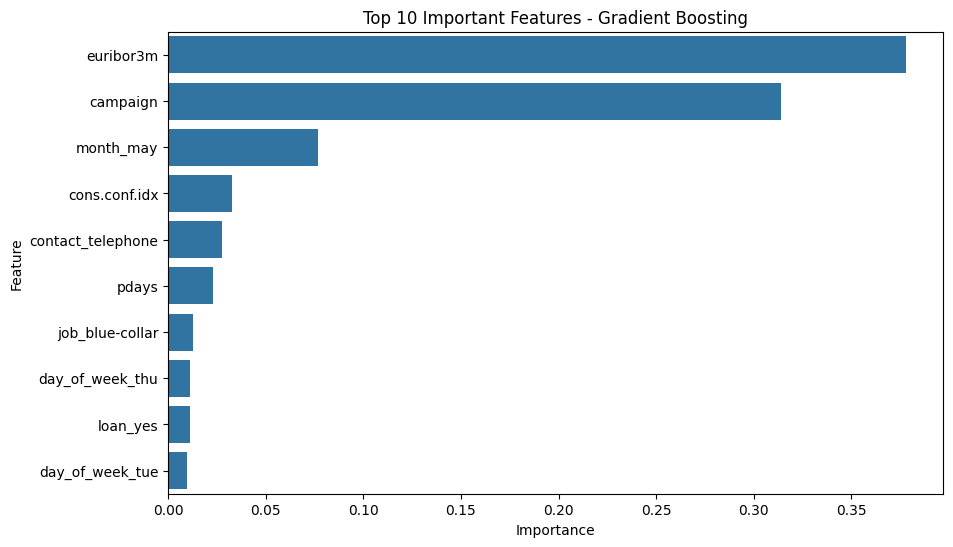

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features - Gradient Boosting')
plt.show()

In [ ]:
#Business Insights


1. Economic conditions strongly influence customer decisions.

The 3-month Euribor interest rate (euribor3m) is the most important feature. This suggests that customers' decisions to subscribe to a term deposit are closely related to market interest rates. The bank should monitor economic conditions and launch deposit campaigns when interest rate trends make savings products more attractive.

2. Avoid contacting customers too many times.

The campaign feature (number of contacts during the current campaign) is the second most important predictor. Repeatedly contacting the same customer does not always improve the chances of subscription and may even reduce customer satisfaction. The bank should determine an optimal number of follow-up calls instead of making excessive contacts.

3. Campaign timing matters.

The importance of month_may indicates that customer response varies across different months. The bank should analyze seasonal trends and schedule marketing campaigns during months when customers are more likely to subscribe.

4. Customer confidence affects subscription.

The Consumer Confidence Index (cons.conf.idx) influences customer decisions. When consumer confidence is higher, customers may be more willing to invest in financial products. The bank should consider current economic sentiment when planning marketing campaigns.

5. Choose the most effective communication channel.

The feature contact_telephone shows that the communication method affects customer response. The bank should compare the performance of telephone and cellular contacts and prioritize the channel that achieves higher subscription rates.

6. Use previous customer interactions.

The pdays feature indicates that the time since the last customer contact influences the likelihood of subscription. Customers who have been contacted recently may respond differently from those who have not been contacted for a long time. The bank can use this information to plan follow-up campaigns more effectively.

7. Target specific customer groups.

The importance of job_blue-collar suggests that occupation influences subscription behavior. The bank can segment customers based on occupation and design marketing messages tailored to different customer groups.

8. Consider the day of contact.

The features day_of_week_thu and day_of_week_tue indicate that customer response varies depending on the day of the week. The bank can analyze which weekdays produce better conversion rates and schedule campaigns accordingly.

9. Consider customers' financial commitments.

The feature loan_yes indicates that customers with existing personal loans may have different subscription behavior. The bank can design financial products or offers specifically for customers with existing loan commitments.